# FinRL-DeepSeek — Ablation Study A→F (Kaggle GPU)

**GPU accelerator must be ON** (Settings → Accelerator → GPU T4 x1)

| Config | Algorithm | M1 Confidence | M2 Reward Shaping | M3 Circuit Breaker |
|--------|-----------|:---:|:---:|:---:|
| A | PPO baseline | — | — | — |
| B | PPO + LLM | — | — | — |
| C | CPPO baseline | — | — | — |
| D | CPPO + Confidence | ✓ | — | — |
| E | CPPO + Shaping | ✓ | ✓ | — |
| F | Full model | ✓ | ✓ | ✓ |

**Estimated runtime on T4 GPU: ~8–12 h total**

## 1. Install dependencies

In [1]:
%%capture
# DO NOT reinstall torch — use Kaggle's pre-installed version (already CUDA-compatible)
!pip install gymnasium yfinance stockstats openai datasets huggingface_hub PyYAML python-dotenv websockets stockstats


In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Quick sanity check — small tensor on GPU
x = torch.randn(10, 10).cuda()
print(f"GPU tensor OK: {x.shape}")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU tensor OK: torch.Size([10, 10])


## 2. Clone repository

In [3]:
import os
REPO = "https://github.com/testS7ven/FinRL_DeepSeek.git"
!git clone {REPO} /kaggle/working/FinRL_DeepSeek
os.chdir("/kaggle/working/FinRL_DeepSeek")
print("Working directory:", os.getcwd())

Cloning into '/kaggle/working/FinRL_DeepSeek'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 115 (delta 46), reused 114 (delta 45), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 1.26 MiB | 23.39 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Working directory: /kaggle/working/FinRL_DeepSeek


## 3. Check GPU

In [4]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 4. GPU-patched training functions

We monkey-patch `ppo_train` and `cppo_train` to move the agent and tensors to GPU.

In [5]:
import sys
sys.path.insert(0, "/kaggle/working/FinRL_DeepSeek")

import time
import numpy as np
import torch
from pathlib import Path

from risk_first.training.networks import ActorCritic
from risk_first.training.buffer import PPOBuffer, CPPOBuffer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def ppo_train_gpu(env, cfg, save_dir="risk_first/models", run_name="ppo", log_path=None):
    torch.manual_seed(cfg.get("seed", 42))
    np.random.seed(cfg.get("seed", 42))

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    hidden  = cfg.get("hidden_sizes", [512, 512])

    agent = ActorCritic(obs_dim, act_dim, hidden).to(DEVICE)
    pi_opt = torch.optim.Adam(
        list(agent.pi_net.parameters()) + [agent.log_std], lr=cfg["pi_lr"]
    )
    v_opt = torch.optim.Adam(agent.v_net.parameters(), lr=cfg["vf_lr"])

    buf = PPOBuffer(obs_dim, act_dim, size=cfg["steps_per_epoch"],
                   gamma=cfg["gamma"], lam=cfg.get("lam", 0.97))

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    logs = []
    last_portfolio_history = []
    obs, _ = env.reset()
    ep_ret = 0.0

    for epoch in range(cfg["epochs"]):
        t0 = time.time()
        ep_rets = []
        portfolio_hist = []

        for step in range(cfg["steps_per_epoch"]):
            # act on GPU
            with torch.no_grad():
                obs_t = torch.as_tensor(obs, dtype=torch.float32).to(DEVICE)
                dist, v = agent(obs_t)
                a = dist.sample()
                a_clipped = torch.clamp(a, -1.0, 1.0)
                logp = dist.log_prob(a_clipped).sum()
                act_np = a_clipped.cpu().numpy()
                val = float(v.cpu())
                logp_val = float(logp.cpu())

            next_obs, rew, done, _, info = env.step(act_np)
            buf.store(obs, act_np, rew, val, logp_val)
            portfolio_hist.append(info.get("portfolio_value", 0.0))
            ep_ret += rew
            obs = next_obs

            timeout = (step == cfg["steps_per_epoch"] - 1)
            if done or timeout:
                if done:
                    ep_rets.append(ep_ret)
                    buf.finish_path(last_val=0.0)
                else:
                    with torch.no_grad():
                        obs_t2 = torch.as_tensor(obs, dtype=torch.float32).to(DEVICE)
                        _, lv = agent(obs_t2)
                        last_val = float(lv.cpu())
                    buf.finish_path(last_val=last_val)
                obs, _ = env.reset()
                ep_ret = 0.0

        last_portfolio_history = portfolio_hist
        data = buf.get()
        obs_t    = torch.as_tensor(data["obs"],  dtype=torch.float32).to(DEVICE)
        act_t    = torch.as_tensor(data["act"],  dtype=torch.float32).to(DEVICE)
        adv_t    = torch.as_tensor(data["adv"],  dtype=torch.float32).to(DEVICE)
        ret_t    = torch.as_tensor(data["ret"],  dtype=torch.float32).to(DEVICE)
        logp_old = torch.as_tensor(data["logp"], dtype=torch.float32).to(DEVICE)

        kl = 0.0
        for _ in range(cfg["train_pi_iters"]):
            pi_opt.zero_grad()
            logp_new, _, _ = agent.evaluate(obs_t, act_t)
            ratio    = torch.exp(logp_new - logp_old)
            clip_adv = torch.clamp(ratio, 1 - cfg["clip_ratio"], 1 + cfg["clip_ratio"]) * adv_t
            pi_loss  = -torch.min(ratio * adv_t, clip_adv).mean()
            kl = float((logp_old - logp_new).detach().mean())
            if abs(kl) > 1.5 * cfg["target_kl"]:
                break
            pi_loss.backward()
            pi_opt.step()

        for _ in range(cfg["train_v_iters"]):
            v_opt.zero_grad()
            _, v_new, _ = agent.evaluate(obs_t, act_t)
            v_loss = ((v_new - ret_t) ** 2).mean()
            v_loss.backward()
            v_opt.step()

        avg_ret = float(np.mean(ep_rets)) if ep_rets else 0.0
        line = (f"[{run_name}] Epoch {epoch+1:3d}/{cfg['epochs']} | "
                f"AvgEpRet {avg_ret:12.2f} | KL {kl:.4f} | Time {time.time()-t0:.1f}s")
        print(line)
        logs.append(line)

    torch.save(agent.state_dict(), save_path / f"{run_name}_agent.pth")
    if log_path:
        Path(log_path).parent.mkdir(parents=True, exist_ok=True)
        Path(log_path).write_text("\n".join(logs))
    print(f"[{run_name}] Saved to {save_path}/{run_name}_agent.pth")
    return last_portfolio_history


def cppo_train_gpu(env, cfg, cppo_cfg, save_dir="risk_first/models", run_name="cppo", log_path=None):
    torch.manual_seed(cfg.get("seed", 42))
    np.random.seed(cfg.get("seed", 42))

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    hidden  = cfg.get("hidden_sizes", [512, 512])

    agent = ActorCritic(obs_dim, act_dim, hidden).to(DEVICE)
    pi_opt = torch.optim.Adam(
        list(agent.pi_net.parameters()) + [agent.log_std], lr=cfg["pi_lr"]
    )
    v_opt = torch.optim.Adam(agent.v_net.parameters(), lr=cfg["vf_lr"])

    buf = CPPOBuffer(obs_dim, act_dim, size=cfg["steps_per_epoch"],
                    gamma=cfg["gamma"], lam=cfg.get("lam", 0.97))

    alpha     = cppo_cfg["alpha"]
    beta      = cppo_cfg["beta"]
    cvar_clip = cppo_cfg["cvar_clip_ratio"]
    delay     = cppo_cfg["delay"]
    nu = 0.0
    cvarlam = 0.0

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    logs = []
    last_portfolio_history = []
    ep_rets_for_cvar = []
    obs, _ = env.reset()
    ep_ret = 0.0

    for epoch in range(cfg["epochs"]):
        t0 = time.time()
        ep_rets = []
        portfolio_hist = []

        for step in range(cfg["steps_per_epoch"]):
            with torch.no_grad():
                obs_t = torch.as_tensor(obs, dtype=torch.float32).to(DEVICE)
                dist, v = agent(obs_t)
                a = dist.sample()
                a_clipped = torch.clamp(a, -1.0, 1.0)
                logp = dist.log_prob(a_clipped).sum()
                act_np = a_clipped.cpu().numpy()
                val = float(v.cpu())
                logp_val = float(logp.cpu())

            next_obs, rew, done, _, info = env.step(act_np)

            llm_risk_factor = info.get("llm_risk_factor", 1.0)
            adjusted_D = llm_risk_factor * (ep_ret + val - nu)
            if adjusted_D < nu and cvarlam > 0:
                valupdate = delay * cvarlam / (1.0 - alpha) * (nu - adjusted_D)
                valupdate = min(valupdate, abs(val) * cvar_clip)
            else:
                valupdate = 0.0

            buf.store(obs, act_np, rew, val, logp_val, valupdate)
            portfolio_hist.append(info.get("portfolio_value", 0.0))
            ep_ret += rew
            obs = next_obs

            timeout = (step == cfg["steps_per_epoch"] - 1)
            if done or timeout:
                if done:
                    ep_rets.append(ep_ret)
                    ep_rets_for_cvar.append(ep_ret)
                    buf.finish_path(last_val=0.0)
                else:
                    with torch.no_grad():
                        obs_t2 = torch.as_tensor(obs, dtype=torch.float32).to(DEVICE)
                        _, lv = agent(obs_t2)
                        last_val = float(lv.cpu())
                    buf.finish_path(last_val=last_val)
                obs, _ = env.reset()
                ep_ret = 0.0

        last_portfolio_history = portfolio_hist

        if len(ep_rets_for_cvar) >= 2:
            sorted_rets = np.sort(ep_rets_for_cvar)
            tail_idx = max(1, min(int(len(sorted_rets) * (1.0 - alpha)), len(sorted_rets) - 1))
            nu   = float(sorted_rets[tail_idx])
            cvar = -float(sorted_rets[:tail_idx].mean())
            if cvar > beta:
                cvarlam = max(0.0, cvarlam + 0.1 * (cvar - beta))
            else:
                cvarlam = max(0.0, cvarlam - 0.05)
            ep_rets_for_cvar.clear()

        data = buf.get()
        obs_t    = torch.as_tensor(data["obs"],  dtype=torch.float32).to(DEVICE)
        act_t    = torch.as_tensor(data["act"],  dtype=torch.float32).to(DEVICE)
        adv_t    = torch.as_tensor(data["adv"],  dtype=torch.float32).to(DEVICE)
        ret_t    = torch.as_tensor(data["ret"],  dtype=torch.float32).to(DEVICE)
        logp_old = torch.as_tensor(data["logp"], dtype=torch.float32).to(DEVICE)

        kl = 0.0
        for _ in range(cfg["train_pi_iters"]):
            pi_opt.zero_grad()
            logp_new, _, _ = agent.evaluate(obs_t, act_t)
            ratio    = torch.exp(logp_new - logp_old)
            clip_adv = torch.clamp(ratio, 1 - cfg["clip_ratio"], 1 + cfg["clip_ratio"]) * adv_t
            pi_loss  = -torch.min(ratio * adv_t, clip_adv).mean()
            kl = float((logp_old - logp_new).detach().mean())
            if abs(kl) > 1.5 * cfg["target_kl"]:
                break
            pi_loss.backward()
            pi_opt.step()

        for _ in range(cfg["train_v_iters"]):
            v_opt.zero_grad()
            _, v_new, _ = agent.evaluate(obs_t, act_t)
            v_loss = ((v_new - ret_t) ** 2).mean()
            v_loss.backward()
            v_opt.step()

        avg_ret = float(np.mean(ep_rets)) if ep_rets else 0.0
        line = (f"[{run_name}] Epoch {epoch+1:3d}/{cfg['epochs']} | "
                f"AvgEpRet {avg_ret:12.2f} | KL {kl:.4f} | "
                f"nu {nu:.1f} | cvarlam {cvarlam:.4f} | Time {time.time()-t0:.1f}s")
        print(line)
        logs.append(line)

    torch.save(agent.state_dict(), save_path / f"{run_name}_agent.pth")
    if log_path:
        Path(log_path).parent.mkdir(parents=True, exist_ok=True)
        Path(log_path).write_text("\n".join(logs))
    print(f"[{run_name}] Saved to {save_path}/{run_name}_agent.pth")
    return last_portfolio_history


print("GPU-patched trainers ready.")

GPU-patched trainers ready.


## 5. Monkey-patch pipeline & run ablation

In [6]:
import risk_first.pipeline as _pipeline_mod
import risk_first.training.ppo  as _ppo_mod
import risk_first.training.cppo as _cppo_mod

# Replace original trainers with GPU versions
_ppo_mod.ppo_train   = ppo_train_gpu
_cppo_mod.cppo_train = cppo_train_gpu
_pipeline_mod.ppo_train  = ppo_train_gpu
_pipeline_mod.cppo_train = cppo_train_gpu

print("Trainers patched to GPU versions.")

Trainers patched to GPU versions.


## 6. Download HuggingFace data (once)

In [7]:
from pathlib import Path
from risk_first.data.load_hf import load_datasets as load_hf_datasets

cache_dir = Path("risk_first/cache")
if not (cache_dir / "train.csv").exists():
    print("Downloading benstaf/nasdaq_2013_2023 from HuggingFace...")
    load_hf_datasets(cache_dir=str(cache_dir))
    print("Download complete.")
else:
    print("Cache already exists, skipping download.")

[load_hf] Downloading train_data_deepseek_risk_2013_2018.csv from HuggingFace...


train_data_deepseek_risk_2013_2018.csv:   0%|          | 0.00/37.2M [00:00<?, ?B/s]

[load_hf] Downloading trade_data_deepseek_risk_2019_2023.csv from HuggingFace...


trade_data_deepseek_risk_2019_2023.csv:   0%|          | 0.00/31.2M [00:00<?, ?B/s]

[load_hf] Train: 126,756 rows | 84 tickers
[load_hf] Test:  105,588 rows  | 84 tickers
[load_hf] Signal coverage — sentiment: 9.7% | risk: 4.1%
Download complete.


## 7. Run full ablation A→F

> ⚠️ **This cell takes ~8–12 hours on T4 GPU.** Results are saved after each config so you won't lose progress if the session expires.

In [8]:
from risk_first.run_ablation import run_ablation

results = run_ablation(cfg_path="risk_first/config.yaml")
print("\n=== ABLATION COMPLETE ===")


  Running: A_PPO_baseline
[pipeline] Loading pre-processed HuggingFace data from cache...
[A_PPO_baseline] Epoch   1/100 | AvgEpRet         0.00 | KL 7.1754 | Time 30.6s
[A_PPO_baseline] Epoch   2/100 | AvgEpRet        -0.00 | KL 4.9277 | Time 28.8s
[A_PPO_baseline] Epoch   3/100 | AvgEpRet         0.00 | KL 3.9366 | Time 29.0s
[A_PPO_baseline] Epoch   4/100 | AvgEpRet         0.00 | KL 3.0063 | Time 28.7s
[A_PPO_baseline] Epoch   5/100 | AvgEpRet         0.00 | KL 1.7590 | Time 28.3s
[A_PPO_baseline] Epoch   6/100 | AvgEpRet         0.00 | KL 0.9830 | Time 28.8s
[A_PPO_baseline] Epoch   7/100 | AvgEpRet         0.00 | KL 0.8854 | Time 28.4s
[A_PPO_baseline] Epoch   8/100 | AvgEpRet         0.00 | KL 0.5503 | Time 28.7s
[A_PPO_baseline] Epoch   9/100 | AvgEpRet         0.00 | KL 0.6350 | Time 29.2s
[A_PPO_baseline] Epoch  10/100 | AvgEpRet         0.00 | KL 0.2974 | Time 31.8s
[A_PPO_baseline] Epoch  11/100 | AvgEpRet        -0.00 | KL 0.2841 | Time 31.6s
[A_PPO_baseline] Epoch  12/10

## 8. Display results table

In [9]:
import pandas as pd

summary = pd.read_csv("risk_first/results/ablation_summary.csv", index_col=0)
print(summary.to_string(float_format=lambda x: f"{x:.4f}"))
summary

                   cumulative_return  sharpe_ratio  rachev_ratio  outperformance_frequency  max_drawdown
model                                                                                                   
A_PPO_baseline              160.0775        0.7265        0.9148                   52.2709      -58.3667
B_PPO_LLM                   160.0775        0.7265        0.9148                   52.2709      -58.3667
C_CPPO_baseline             160.0775        0.7265        0.9148                   52.2709      -58.3667
D_CPPO_confidence           168.7060        0.7522        0.9260                   52.2709      -57.3693
E_CPPO_shaping              179.7664        0.7732        0.9389                   51.0757      -56.5085
F_full_model                178.9723        0.7843        0.9284                   51.1554      -56.0856


,cumulative_return,sharpe_ratio,rachev_ratio,outperformance_frequency,max_drawdown
model,,,,,
A_PPO_baseline,160.077478,0.726470,0.914785,52.270916,-58.366656
B_PPO_LLM,160.077478,0.726470,0.914785,52.270916,-58.366656
C_CPPO_baseline,160.077478,0.726470,0.914785,52.270916,-58.366656
D_CPPO_confidence,168.705968,0.752217,0.926021,52.270916,-57.369255
E_CPPO_shaping,179.766380,0.773237,0.938853,51.075697,-56.508547
F_full_model,178.972326,0.784303,0.928436,51.155378,-56.085574


## 9. Plot equity curves

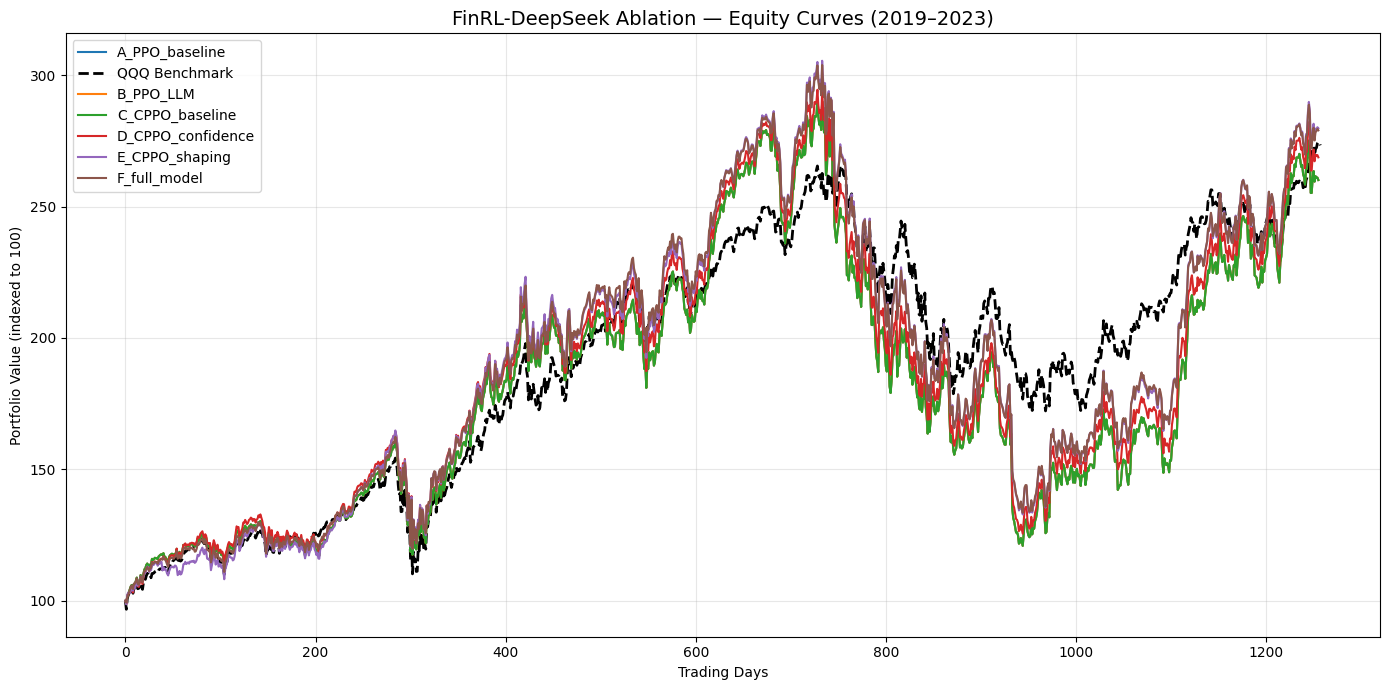

Saved: risk_first/results/equity_curves.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("risk_first/results")
configs = ["A_PPO_baseline", "B_PPO_LLM", "C_CPPO_baseline",
           "D_CPPO_confidence", "E_CPPO_shaping", "F_full_model"]

fig, ax = plt.subplots(figsize=(14, 7))

benchmark_loaded = False
for name in configs:
    eq_path = results_dir / f"{name}_equity.npy"
    bm_path = results_dir / f"{name}_benchmark.npy"
    if eq_path.exists():
        equity = np.load(eq_path)
        ax.plot(equity / equity[0] * 100, label=name, linewidth=1.5)
        if not benchmark_loaded and bm_path.exists():
            bm = np.load(bm_path)
            ax.plot(bm / bm[0] * 100, "k--", label="QQQ Benchmark", linewidth=2)
            benchmark_loaded = True

ax.set_title("FinRL-DeepSeek Ablation — Equity Curves (2019–2023)", fontsize=14)
ax.set_xlabel("Trading Days")
ax.set_ylabel("Portfolio Value (indexed to 100)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("risk_first/results/equity_curves.png", dpi=150)
plt.show()
print("Saved: risk_first/results/equity_curves.png")

## 10. Download all results as ZIP

In [11]:
import shutil
shutil.make_archive("/kaggle/working/finrl_results", "zip", "risk_first/results")
print("Results zipped: /kaggle/working/finrl_results.zip")
print("Download it from: Kaggle sidebar → Output → finrl_results.zip")

Results zipped: /kaggle/working/finrl_results.zip
Download it from: Kaggle sidebar → Output → finrl_results.zip


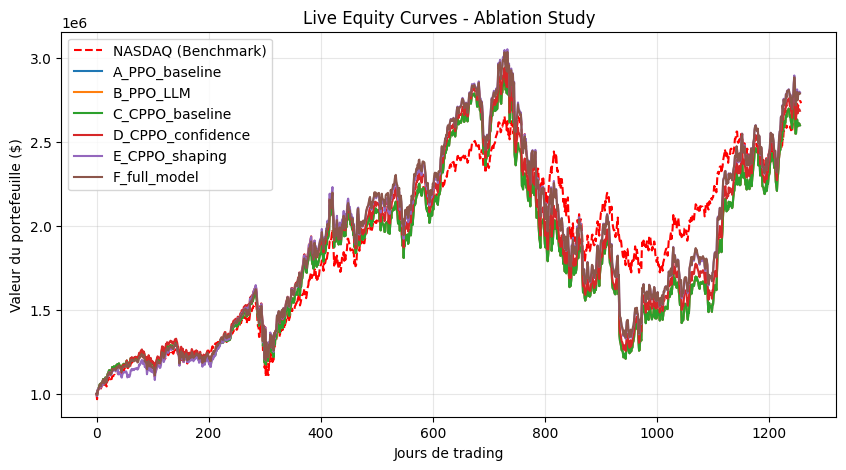

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

res_path = Path("risk_first/results")
configs = ["A_PPO_baseline", "B_PPO_LLM", "C_CPPO_baseline", 
           "D_CPPO_confidence", "E_CPPO_shaping", "F_full_model"]

plt.figure(figsize=(10, 5))

# Afficher le Benchmark (NASDAQ) s'il existe
bench_file = res_path / "A_PPO_baseline_benchmark.npy"
if bench_file.exists():
    plt.plot(np.load(bench_file), label="NASDAQ (Benchmark)", color="red", linestyle="--")

# Afficher toutes les courbes déjà calculées
for cfg in configs:
    eq_file = res_path / f"{cfg}_equity.npy"
    if eq_file.exists():
        plt.plot(np.load(eq_file), label=cfg)

plt.title("Live Equity Curves - Ablation Study")
plt.xlabel("Jours de trading")
plt.ylabel("Valeur du portefeuille ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
